# Objective 2 - Part 2 (Nishan): FIFA ranking and rating

**Question:** how strong was each team going into the tournament, using the Fifa World Ranking
(11 June 2026 edition, the last one published before the tournament started)?

**Why it matters:** this is the single strongest pre-match signal of team strength.
Before using it in a model, this notebook checks the data is complete, internally
consistent, and actually related to match results.

In [29]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

from common import load_matches, load_team_matches, RAW, PROCESSED, FIGURES, RESULTS

pd.set_option("display.width", 150)

In [30]:
rank = pd.read_csv(RAW / "fifa_ranking_raw.csv")
print(f"Rows: {len(rank)} | Duplicate teams: {rank['Team'].duplicated().sum()}")
rank.head(10)

Rows: 48 | Duplicate teams: 0


,Team,FIFA_Rank,FIFA_Points
0,Argentina,1,1877.27
1,Spain,2,1874.71
2,France,3,1870.70
3,England,4,1828.02
4,Portugal,5,1767.85
5,Brazil,6,1765.86
6,Morocco,7,1755.10
7,Netherlands,8,1753.57
8,Belgium,9,1742.24
9,Germany,10,1735.77


In [31]:
# The 48 teams here must be EXACTLY the 48 teams that played in the tournament,
# using the same spelling as common.py, or the merge in a later step will silently
# drop rows. This checks both directions.
tm = load_team_matches()
tournament_teams = set(tm["Team"])
ranking_teams = set(rank["Team"])

missing_from_ranking = tournament_teams - ranking_teams
extra_in_ranking = ranking_teams - tournament_teams

print(f"Teams in fixtures : {len(tournament_teams)}")
print(f"Teams in ranking  : {len(ranking_teams)}")
print(f"In fixtures but NOT in ranking file: {missing_from_ranking or 'none'}")
print(f"In ranking file but NOT in fixtures: {extra_in_ranking or 'none'}")
assert not missing_from_ranking, "every World Cup team must have a ranking"

Teams in fixtures : 48
Teams in ranking  : 48
In fixtures but NOT in ranking file: none
In ranking file but NOT in fixtures: none


In [32]:
# Data-entry check: a lower rank number should always mean more points.
# If this table is non-empty, the rank and points columns disagree somewhere
# and need to be re-checked against the source.
check = rank.sort_values("FIFA_Rank").copy()
check["Points_Should_Decrease"] = check["FIFA_Points"].diff() > 0
problems = check[check["Points_Should_Decrease"]]
print(f"Rows where points increase as rank gets worse (should be empty): {len(problems)}")
problems

Rows where points increase as rank gets worse (should be empty): 0


,Team,FIFA_Rank,FIFA_Points,Points_Should_Decrease


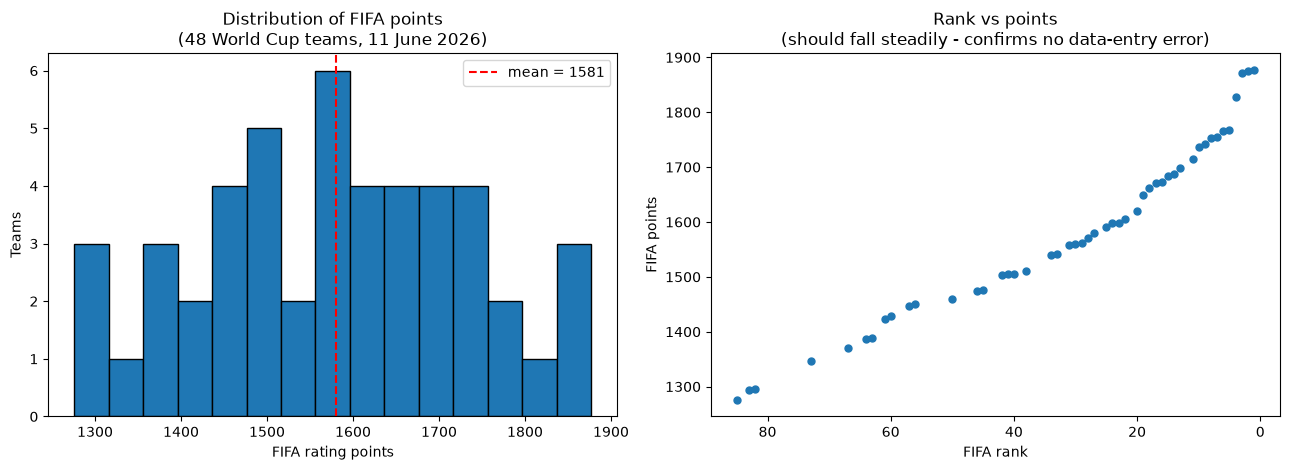

count      48.0
mean     1580.7
std       157.2
min      1275.6
25%      1470.5
50%      1575.2
75%      1690.2
max      1877.3


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(rank["FIFA_Points"], bins=15, edgecolor="black")
axes[0].axvline(rank["FIFA_Points"].mean(), color="red", linestyle="--",
                label=f"mean = {rank['FIFA_Points'].mean():.0f}")
axes[0].set_xlabel("FIFA rating points"); axes[0].set_ylabel("Teams")
axes[0].set_title("Distribution of FIFA points\n(48 World Cup teams, 11 June 2026)")
axes[0].legend()

axes[1].scatter(rank["FIFA_Rank"], rank["FIFA_Points"], s=25)
axes[1].set_xlabel("FIFA rank"); axes[1].set_ylabel("FIFA points")
axes[1].set_title("Rank vs points\n(should fall steadily - confirms no data-entry error)")
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig(FIGURES / "nishan_ranking_distribution.png", dpi=150)
plt.show()

print(rank["FIFA_Points"].describe().round(1).to_string())

In [34]:
# Points are on an arbitrary scale (roughly 700-1900) and are not directly
# comparable to the other 0-to-1 features used in the models. A z-score
# (how many standard deviations above/below the 48-team average) is easier
# to interpret and puts FIFA_Points on a similar footing to the other
# variables when we later compare standardised coefficients.
rank["FIFA_Points_Z"] = (rank["FIFA_Points"] - rank["FIFA_Points"].mean()) / rank["FIFA_Points"].std()

rank.sort_values("FIFA_Rank")[["FIFA_Rank", "Team", "FIFA_Points", "FIFA_Points_Z"]].head(8)

,FIFA_Rank,Team,FIFA_Points,FIFA_Points_Z
0,1,Argentina,1877.27,1.886108
1,2,Spain,1874.71,1.869828
2,3,France,1870.70,1.844326
3,4,England,1828.02,1.572896
4,5,Portugal,1767.85,1.190236
5,6,Brazil,1765.86,1.177580
6,7,Morocco,1755.10,1.109150
7,8,Netherlands,1753.57,1.099420


In [35]:
# Sanity check: if the ranking is a meaningful measure of team strength, the
# higher-ranked team should win more often than chance. This checks the
# ranking against match results WITHOUT using it to build a model yet 
# purely a validity check on the data before it goes anywhere near a
# regression.
m = load_matches()
m = m.merge(rank[["Team", "FIFA_Rank"]], left_on="Team_A", right_on="Team", how="left") \
     .rename(columns={"FIFA_Rank": "Rank_A"}).drop(columns="Team") \
     .merge(rank[["Team", "FIFA_Rank"]], left_on="Team_B", right_on="Team", how="left") \
     .rename(columns={"FIFA_Rank": "Rank_B"}).drop(columns="Team")

assert m[["Rank_A", "Rank_B"]].isna().sum().sum() == 0, "some teams failed to merge"

m["Favourite_Is_A"] = m["Rank_A"] < m["Rank_B"]          # lower rank number = stronger
m["Favourite_Won"] = np.where(m["Favourite_Is_A"], m["Goal_Diff"] > 0, m["Goal_Diff"] < 0)
m["Favourite_Drew"] = m["Goal_Diff"] == 0

win_rate = m["Favourite_Won"].mean()
draw_rate = m["Favourite_Drew"].mean()
print(f"Matches: {len(m)}")
print(f"Higher-ranked team won:  {win_rate:.1%}")
print(f"Match was a draw:        {draw_rate:.1%}")
print(f"Higher-ranked team lost: {1 - win_rate - draw_rate:.1%}")
print("\n(If the ranking carried no information, 'won' would be close to 50% of the non-draw matches.)")

Matches: 104
Higher-ranked team won:  65.4%
Match was a draw:        23.1%
Higher-ranked team lost: 11.5%

(If the ranking carried no information, 'won' would be close to 50% of the non-draw matches.)


                 Favourite_Win_Rate  Matches
Rank_Gap_Bucket                             
0-5                            0.43       14
6-15                           0.62       26
16-30                          0.75       24
31+                            0.70       40


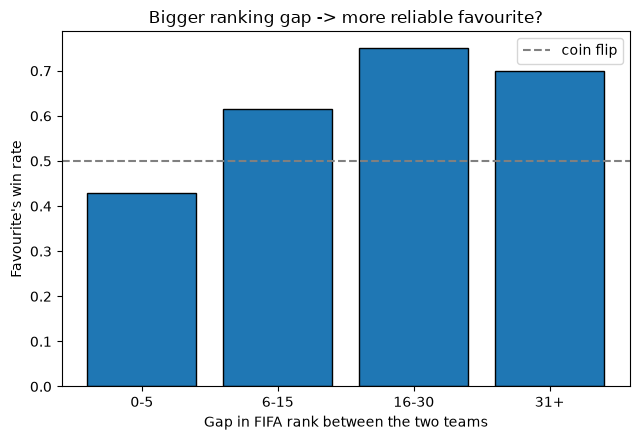

In [36]:
# Same check split by how big the ranking gap is: a bigger gap should mean a
# more reliable favourite, if the ranking is genuinely informative.
m["Rank_Gap"] = (m["Rank_A"] - m["Rank_B"]).abs()
m["Rank_Gap_Bucket"] = pd.cut(m["Rank_Gap"], bins=[0, 5, 15, 30, 210],
                              labels=["0-5", "6-15", "16-30", "31+"])

by_gap = m.groupby("Rank_Gap_Bucket", observed=True)["Favourite_Won"].agg(["mean", "count"])
by_gap.columns = ["Favourite_Win_Rate", "Matches"]
print(by_gap.round(2).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(by_gap.index.astype(str), by_gap["Favourite_Win_Rate"], edgecolor="black")
ax.axhline(0.5, color="grey", linestyle="--", label="coin flip")
ax.set_xlabel("Gap in FIFA rank between the two teams")
ax.set_ylabel("Favourite's win rate")
ax.set_title("Bigger ranking gap -> more reliable favourite?")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "nishan_favourite_win_rate.png", dpi=150)
plt.show()

In [37]:
out = rank[["Team", "FIFA_Rank", "FIFA_Points", "FIFA_Points_Z"]].sort_values("FIFA_Rank").reset_index(drop=True)
out.round(4).to_csv(PROCESSED / "features_fifa_rating.csv", index=False)
print(f"Saved {len(out)} rows -> data/clean/features_fifa_rating.csv")
out.head(6)

Saved 48 rows -> data/clean/features_fifa_rating.csv


,Team,FIFA_Rank,FIFA_Points,FIFA_Points_Z
0,Argentina,1,1877.27,1.886108
1,Spain,2,1874.71,1.869828
2,France,3,1870.70,1.844326
3,England,4,1828.02,1.572896
4,Portugal,5,1767.85,1.190236
5,Brazil,6,1765.86,1.177580
